# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [23]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

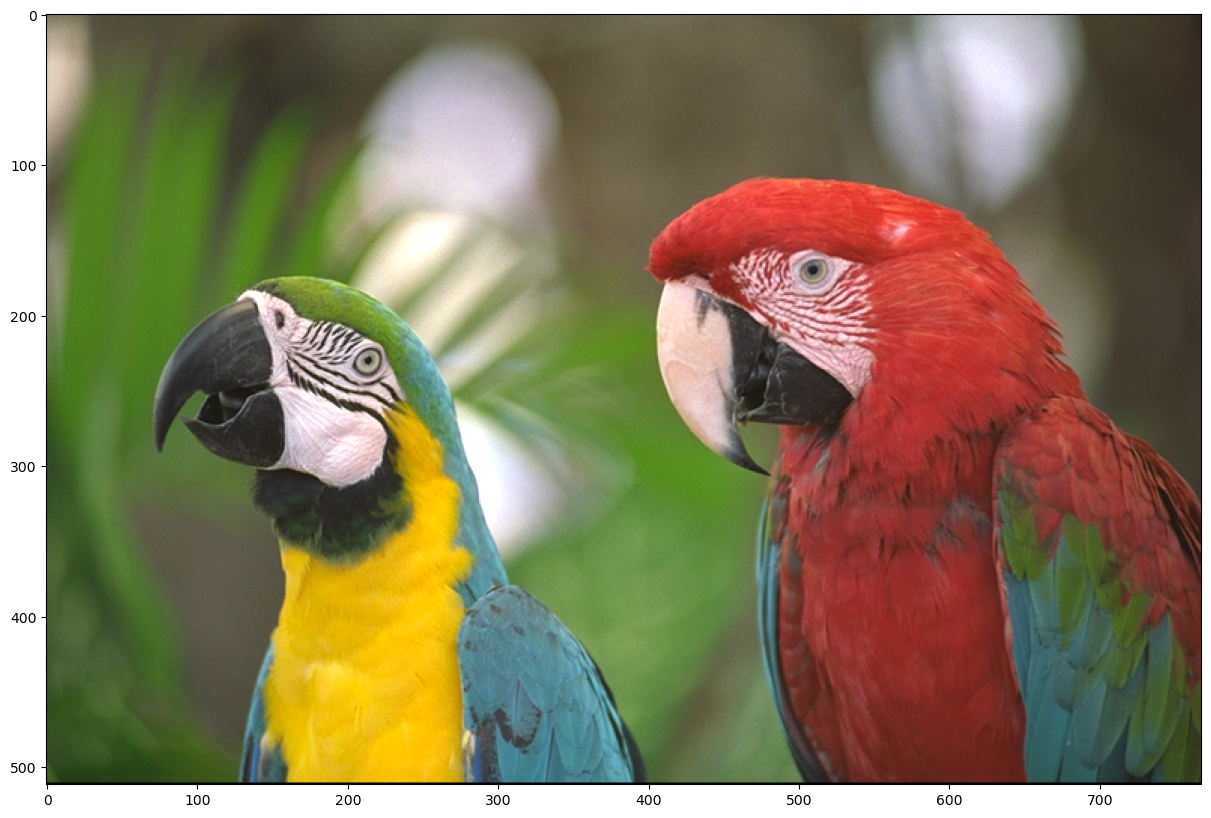

In [24]:
# Load image
img = cv2.imread('./kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [25]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [26]:
# Cast the image to float
img = img.astype(float)

def quantize(img, colors):
    """
    Quantize the image using the provided colors.

    Parameters:
        img (numpy.ndarray): The input image to be quantized.
        colors (numpy.ndarray): The color palette for quantization.

    Returns:
        numpy.ndarray: The quantized image.
    """
    # Prepare for quantization
    rows, cols, channels = img.shape
    quantized = np.zeros_like(img)

    # Apply quantization
    for r in range(rows):
        for c in range(cols):
            # Extract the original pixel value
            pixel = img[r, c, :]

            # Find the closest colour from the pallette (using absolute value/Euclidean distance)
            # Note: You may need more than one line of code here
            new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]

            # Apply quantization
            quantized[r, c, :] = new_pixel

    return quantized

quantized = quantize(img, colors)

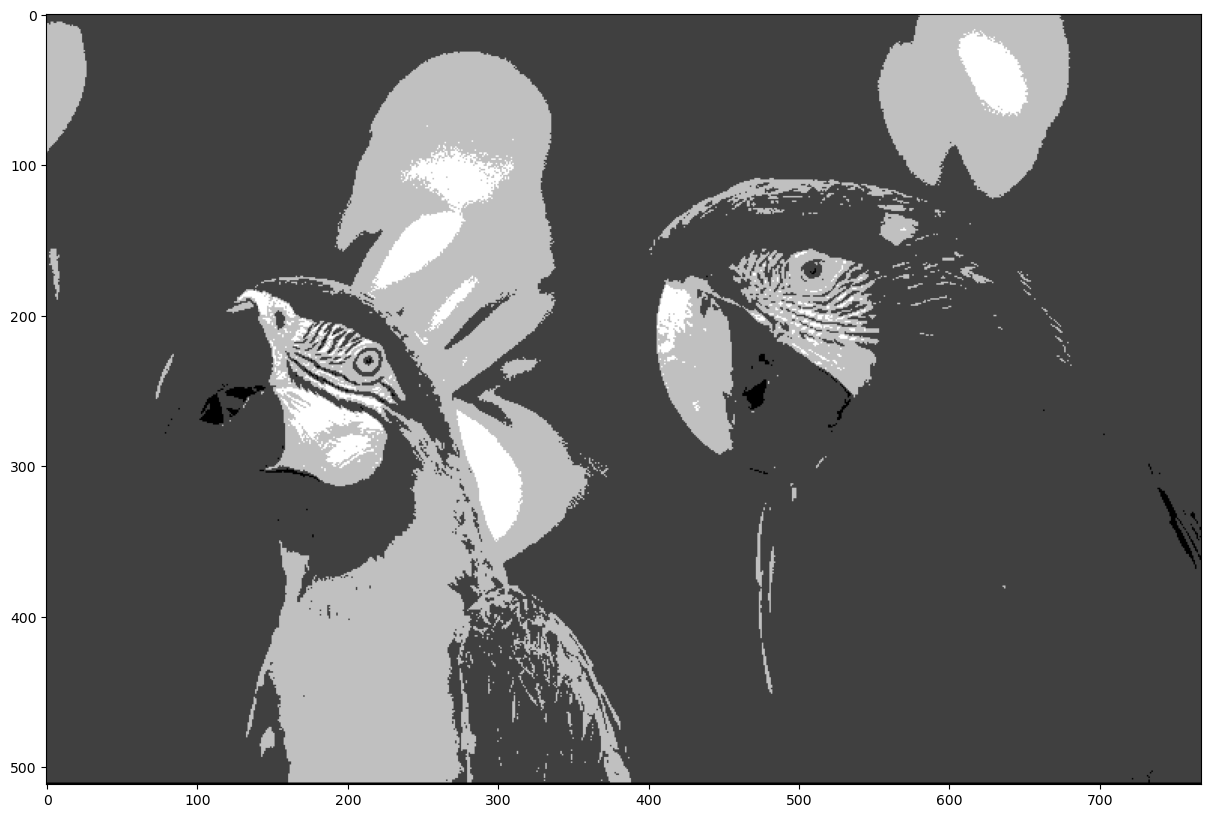

In [27]:
# Show quantized image (don't forget to cast back to uint8)
plt.imshow(quantized.astype(np.uint8))

In [28]:
# Compute average quantization error
avg_quant_error = np.mean(np.linalg.norm(img - quantized, axis=2))
print(f'Average quantization error: {avg_quant_error:.2f}')

Average quantization error: 67.73


#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [29]:
def dither(img, colors):
    """
    Apply Floyd-Steinberg dithering to the image using the provided colors.

    Parameters:
        img (numpy.ndarray): The input image to be dithered.
        colors (numpy.ndarray): The color palette for dithering.
    Returns:
        numpy.ndarray: The dithered image.
    """
    # Prepare for dithering
    rows, cols, channels = img.shape
    dithering = np.zeros_like(img)
    # Make a temporal copy of the original image, we will need it for error diffusion
    img_tmp = np.copy(img)

    # Apply dithering
    for r in range(1, rows-1):
        for c in range(1, cols-1):
            # Extract the original pixel value
            pixel = img_tmp[r, c, :]

            # Find the closest colour from the pallette (using absolute value/Euclidean distance)
            # Note: You may need more than one line of code here
            new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]

            # Compute quantization error
            quant_error = pixel - new_pixel

            # Diffuse the quantization error accroding to the FS diffusion matrix
            # Note: You may need more than one line of code here
            img_tmp[r, c, :] = new_pixel
            img_tmp[r, c+1, :] += quant_error * 7/16
            img_tmp[r+1, c-1, :] += quant_error * 3/16
            img_tmp[r+1, c, :] += quant_error * 5/16
            img_tmp[r+1, c+1, :] += quant_error * 1/16

            # Apply dithering
            dithering[r, c, :] = new_pixel

    return dithering

dithered = dither(img, colors)

(<Axes: >, <matplotlib.image.AxesImage at 0x177bfc190>)

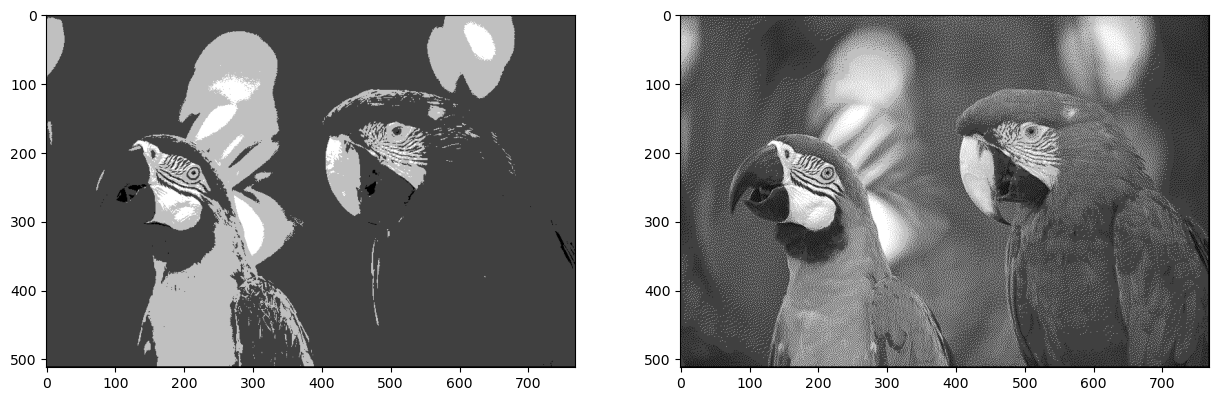

In [30]:
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121), plt.imshow(quantized.astype(np.uint8))   # optimally quantized
plt.subplot(122), plt.imshow(dithered.astype(np.uint8))   # dithering

In [31]:
# Compute average quantization error for dithered image
avg_dith_error = np.mean(np.linalg.norm(img - dithered, axis=2))
print(f'Average dithering error: {avg_dith_error:.2f}')

Average dithering error: 82.23


### Questions
* Which image has higher quantization error? Optimally quantized or dithered?
* Which image looks better to you?
* Can you repeat the same process using only two colours: black and white? Show me :-)

* Quantization error is higher for dithered image.
* Dithered image looks better, of course.

Average quantization error: 152.54
Average dithering error: 193.10


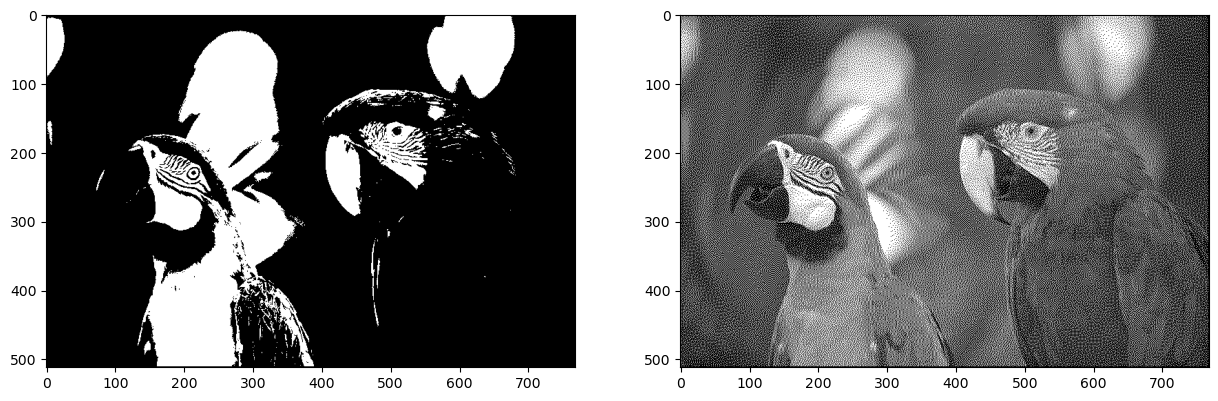

In [34]:
colors = np.array([[0, 0, 0], [255, 255, 255]])

quantized_bw = quantize(img, colors)
dithered_bw = dither(img, colors)

plt.subplot(121), plt.imshow(quantized_bw.astype(np.uint8))   # optimally quantized
plt.subplot(122), plt.imshow(dithered_bw.astype(np.uint8))   # dithering

avg_quant_error = np.mean(np.linalg.norm(img - quantized_bw, axis=2))
print(f'Average quantization error: {avg_quant_error:.2f}')

avg_dith_error = np.mean(np.linalg.norm(img - dithered_bw, axis=2))
print(f'Average dithering error: {avg_dith_error:.2f}')